# EDA 12.1: Payment Method Distribution Analysis

This notebook analyzes payment method distribution, average payment value by method, cancellation behavior by payment method, and leakage-safe historical payment features for forecasting or explainability.

## 1. Setup and File Discovery

Locate `payments.csv` and `orders.csv` anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['payments.csv', 'orders.csv']
REQUIRED = set(FILES)

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,payments.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...
1,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...


## 2. Load Payments and Orders

Load both files safely with pandas and display raw schema context.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
payments = data.get('payments')
orders = data.get('orders')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,payments,True,646945,"order_id, payment_method, payment_value, insta..."
1,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."


## 3. Identify Payment, Order, Method, Amount, Status, Cancellation, and Date Columns

Use tolerant matching for naming variations. If payment date is missing in `payments.csv`, the notebook uses `orders.order_date` as the transaction date proxy and labels that clearly.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

payment_cols = {}
if payments is not None:
    payment_cols = {
        'payment_id': find_column(payments.columns, ['payment_id', 'transaction_id', 'id'], contains=True),
        'order_id': find_column(payments.columns, ['order_id']),
        'payment_date': find_column(payments.columns, ['payment_date', 'transaction_date', 'date', 'created_at'], contains=True),
        'payment_method': find_column(payments.columns, ['payment_method', 'method', 'payment_type', 'payment_channel'], contains=True),
        'payment_amount': find_column(payments.columns, ['payment_amount', 'payment_value', 'amount', 'value', 'paid_amount'], contains=True),
        'payment_status': find_column(payments.columns, ['payment_status', 'status', 'transaction_status'], contains=True),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
        'cancel_flag': find_column(orders.columns, ['is_cancelled', 'is_canceled', 'cancelled_flag', 'canceled_flag', 'cancel_flag'], contains=True),
        'order_total': find_column(orders.columns, ['order_total', 'revenue', 'amount', 'total', 'gmv'], contains=True),
        'payment_method': find_column(orders.columns, ['payment_method', 'method'], contains=True),
    }

identified = pd.DataFrame({'payments': pd.Series(payment_cols), 'orders': pd.Series(orders_cols)})
display(identified)

if payments is not None and payment_cols.get('payment_method') is None:
    warnings.warn('Payment method column could not be identified reliably. Method-level analysis may be skipped.')

,payments,orders
cancel_flag,NaN,None
order_date,NaN,order_date
order_id,order_id,order_id
order_status,NaN,order_status
order_total,NaN,None
payment_amount,payment_value,NaN
payment_date,None,NaN
payment_id,order_id,NaN
payment_method,payment_method,payment_method
payment_status,None,NaN


## 4. Payment Data Quality Checks

Standardize payment method labels, payment amount, and date fields, then inspect missingness, duplicates, and unusual values.

In [4]:
payment_warnings = []
payments_clean = None

def standardize_payment_method(value):
    if pd.isna(value):
        return np.nan
    raw = str(value).strip().lower()
    raw = re.sub(r'[^a-z0-9]+', '_', raw).strip('_')
    mapping = {
        'creditcard': 'credit_card',
        'credit_card': 'credit_card',
        'card': 'credit_card',
        'cod': 'cod',
        'cash_on_delivery': 'cod',
        'cashondelivery': 'cod',
        'banktransfer': 'bank_transfer',
        'bank_transfer': 'bank_transfer',
        'wire_transfer': 'bank_transfer',
        'applepay': 'apple_pay',
        'apple_pay': 'apple_pay',
        'paypal': 'paypal',
        'ewallet': 'ewallet',
        'e_wallet': 'ewallet',
    }
    return mapping.get(raw, raw)

if payments is not None:
    payments_clean = payments.copy()
    payments_clean['order_id_std'] = payments_clean[payment_cols['order_id']] if payment_cols.get('order_id') else pd.NA
    payments_clean['payment_method_std'] = payments_clean[payment_cols['payment_method']].map(standardize_payment_method) if payment_cols.get('payment_method') else np.nan
    payments_clean['payment_amount_std'] = pd.to_numeric(payments_clean[payment_cols['payment_amount']], errors='coerce') if payment_cols.get('payment_amount') else np.nan
    payments_clean['payment_status_std'] = payments_clean[payment_cols['payment_status']].astype(str).str.strip().str.lower() if payment_cols.get('payment_status') else pd.NA
    payments_clean['payment_date_std'] = pd.to_datetime(payments_clean[payment_cols['payment_date']], errors='coerce') if payment_cols.get('payment_date') else pd.NaT
    payments_clean['payment_id_std'] = payments_clean[payment_cols['payment_id']] if payment_cols.get('payment_id') else pd.NA

    duplicate_payment_id = 0
    if payment_cols.get('payment_id'):
        duplicate_payment_id = int(payments_clean.duplicated(subset=['payment_id_std']).sum())
    duplicate_order_payment = int(payments_clean.duplicated(subset=[c for c in ['order_id_std', 'payment_method_std', 'payment_amount_std'] if c in payments_clean.columns]).sum())

    quality = pd.DataFrame([{
        'payment_rows': len(payments_clean),
        'unique_payment_methods': payments_clean['payment_method_std'].nunique(dropna=True),
        'payment_date_min': payments_clean['payment_date_std'].min(),
        'payment_date_max': payments_clean['payment_date_std'].max(),
        'missing_payment_methods': int(payments_clean['payment_method_std'].isna().sum()),
        'missing_payment_amounts': int(payments_clean['payment_amount_std'].isna().sum()),
        'missing_order_ids': int(payments_clean['order_id_std'].isna().sum()),
        'duplicate_payment_ids': duplicate_payment_id,
        'duplicate_order_payment_records': duplicate_order_payment,
        'zero_payment_amounts': int(payments_clean['payment_amount_std'].fillna(0).eq(0).sum()),
        'negative_payment_amounts': int(payments_clean['payment_amount_std'].fillna(0).lt(0).sum()),
    }])
    display(quality)
    if payment_cols.get('payment_amount'):
        display(payments_clean['payment_amount_std'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame('payment_value_summary'))
    if quality.loc[0, 'missing_payment_methods'] > 0:
        payment_warnings.append(f"{quality.loc[0, 'missing_payment_methods']} payment rows have missing payment methods")
    if quality.loc[0, 'negative_payment_amounts'] > 0:
        payment_warnings.append(f"{quality.loc[0, 'negative_payment_amounts']} payment rows have negative amounts")
else:
    warnings.warn('payments.csv not available.')

,payment_rows,unique_payment_methods,payment_date_min,payment_date_max,missing_payment_methods,missing_payment_amounts,missing_order_ids,duplicate_payment_ids,duplicate_order_payment_records,zero_payment_amounts,negative_payment_amounts
0,646945,5,NaT,NaT,0,0,0,0,0,0,0


,payment_value_summary
count,"646,945.0000"
mean,"24,238.3344"
std,"22,378.4753"
min,389.7400
25%,"7,681.0600"
50%,"17,229.4400"
75%,"33,706.3500"
90%,"55,476.3000"
max,"331,570.4000"


## 5. Join Payments with Orders

Bring in order date and order status using `order_id`. This also provides a fallback transaction date when payment date is missing.

In [5]:
orders_clean = None
payments_orders = pd.DataFrame()
join_warnings = []

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['order_status_std'] = orders_clean[orders_cols['order_status']].astype(str).str.strip().str.lower() if orders_cols.get('order_status') else pd.NA
    orders_clean['cancel_flag_std'] = orders_clean[orders_cols['cancel_flag']] if orders_cols.get('cancel_flag') else pd.NA
    orders_clean['order_total_std'] = pd.to_numeric(orders_clean[orders_cols['order_total']], errors='coerce') if orders_cols.get('order_total') else np.nan
    orders_clean['order_payment_method_std'] = orders_clean[orders_cols['payment_method']].map(standardize_payment_method) if orders_cols.get('payment_method') else np.nan

if payments_clean is not None and orders_clean is not None and 'order_id_std' in payments_clean.columns and 'order_id_std' in orders_clean.columns:
    keep_cols = ['order_id_std', 'order_date_std', 'order_status_std', 'cancel_flag_std', 'order_total_std', 'order_payment_method_std']
    payments_orders = payments_clean.merge(orders_clean[keep_cols], on='order_id_std', how='left', indicator=True)
    if payment_cols.get('payment_date') is None:
        payments_orders['payment_date_std'] = payments_orders['order_date_std']
    if payment_cols.get('payment_amount') is None and orders_cols.get('order_total'):
        payments_orders['payment_amount_std'] = payments_orders['order_total_std']

    join_quality = pd.DataFrame([{
        'payment_rows_matched_to_orders': int((payments_orders['_merge'] == 'both').sum()),
        'payment_rows_unmatched_to_orders': int((payments_orders['_merge'] == 'left_only').sum()),
        'orders_without_payment_records': int(~orders_clean['order_id_std'].isin(payments_clean['order_id_std']).sum() if False else (~orders_clean['order_id_std'].isin(payments_clean['order_id_std'])).sum()),
        'orders_with_duplicate_payments': int(payments_orders.groupby('order_id_std').size().gt(1).sum()),
    }])
    display(join_quality)
    unmatched = payments_orders.loc[payments_orders['_merge'] == 'left_only', ['order_id_std', 'payment_method_std', 'payment_amount_std']].head(10)
    if not unmatched.empty:
        display(unmatched)
    if join_quality.loc[0, 'payment_rows_unmatched_to_orders'] > 0:
        join_warnings.append(f"{join_quality.loc[0, 'payment_rows_unmatched_to_orders']} payment rows did not match orders")
else:
    payments_orders = payments_clean.copy() if payments_clean is not None else pd.DataFrame()

,payment_rows_matched_to_orders,payment_rows_unmatched_to_orders,orders_without_payment_records,orders_with_duplicate_payments
0,646945,0,0,0


## 6. Define Payment and Cancellation Metrics

Use order status first for cancellation. Payment status is supporting context only if present.

In [6]:
cancel_words = ['cancelled', 'canceled', 'failed', 'voided']
completed_words = ['delivered', 'paid', 'completed', 'success', 'shipped']
return_words = ['returned', 'refunded']

if not payments_orders.empty:
    status_source_note = []
    order_status_text = payments_orders['order_status_std'].astype(str).str.lower() if 'order_status_std' in payments_orders.columns else pd.Series('', index=payments_orders.index)
    payment_status_text = payments_orders['payment_status_std'].astype(str).str.lower() if 'payment_status_std' in payments_orders.columns else pd.Series('', index=payments_orders.index)

    payments_orders['is_cancelled_order'] = (
        order_status_text.str.contains('|'.join(cancel_words), na=False)
        | payments_orders.get('cancel_flag_std', pd.Series(False, index=payments_orders.index)).fillna(False).astype(str).str.lower().isin(['1', 'true', 'yes'])
    )
    payments_orders['is_returned_order'] = order_status_text.str.contains('|'.join(return_words), na=False)
    payments_orders['is_failed_payment'] = payment_status_text.str.contains('failed|voided|declined', na=False) if payment_cols.get('payment_status') else False
    payments_orders['is_completed_payment'] = payment_status_text.str.contains('paid|completed|success', na=False) if payment_cols.get('payment_status') else False

    if orders_cols.get('order_status'):
        status_source_note.append('Cancellation uses orders.order_status plus any explicit cancel flag when available.')
    elif payment_cols.get('payment_status'):
        status_source_note.append('Cancellation proxy uses payment_status only because order_status is unavailable.')
    else:
        status_source_note.append('Cancellation status is unavailable; cancel-rate analysis may be limited.')

    print('\n'.join(status_source_note))

C:\Users\ACER\AppData\Local\Temp\ipykernel_9376\1086623274.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | payments_orders.get('cancel_flag_std', pd.Series(False, index=payments_orders.index)).fillna(False).astype(str).str.lower().isin(['1', 'true', 'yes'])


Cancellation uses orders.order_status plus any explicit cancel flag when available.


## 7. Payment Method Distribution

Summarize count share and value share by payment method.

,payment_method_std,payment_count,order_count,total_payment_value,payment_method_share,payment_value_share
3,credit_card,356352,356352,"8,630,069,413.1900",0.5508,0.5504
4,paypal,97018,97018,"2,363,680,137.7300",0.1500,0.1507
2,cod,96681,96681,"2,346,947,592.9300",0.1494,0.1497
0,apple_pay,64763,64763,"1,564,269,610.5000",0.1001,0.0998
1,bank_transfer,32131,32131,"775,902,511.0800",0.0497,0.0495


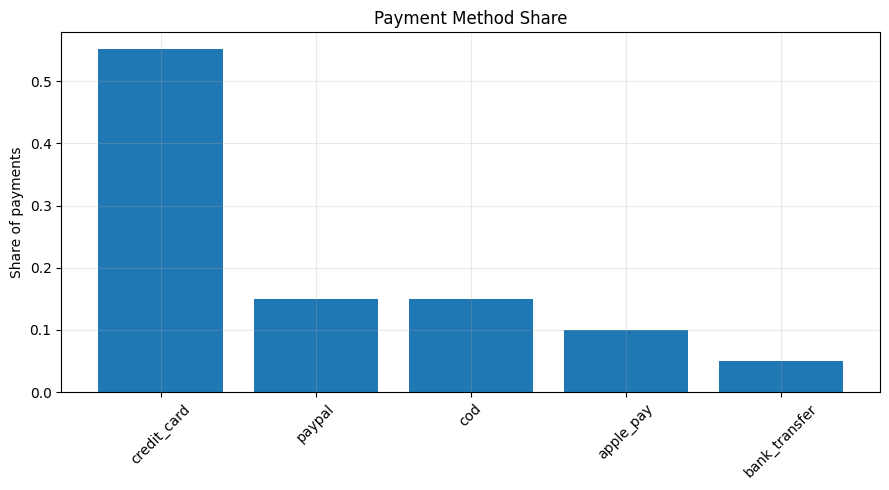

In [7]:
method_summary = pd.DataFrame()

if not payments_orders.empty and 'payment_method_std' in payments_orders.columns:
    method_summary = payments_orders.groupby('payment_method_std').agg(
        payment_count=('order_id_std', 'size'),
        order_count=('order_id_std', 'nunique'),
        total_payment_value=('payment_amount_std', 'sum'),
    ).reset_index()
    method_summary['payment_method_share'] = method_summary['payment_count'] / method_summary['payment_count'].sum()
    method_summary['payment_value_share'] = method_summary['total_payment_value'] / method_summary['total_payment_value'].sum()
    method_summary = method_summary.sort_values('payment_count', ascending=False)
    display(method_summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(method_summary['payment_method_std'].astype(str), method_summary['payment_method_share'], color='tab:blue')
    ax.set_title('Payment Method Share')
    ax.set_ylabel('Share of payments')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Payment method distribution cannot be built because payment_method is unavailable.')

## 8. Average Payment Value by Method

Compare average and median payment value by method and avoid over-reading sparse methods.

,payment_method_std,payment_count,avg_payment_value,median_payment_value,std_payment_value,p25_payment_value,p75_payment_value,p90_payment_value,total_payment_value
4,paypal,97018,"24,363.3154","17,331.9500","22,413.1387","7,718.1125","34,003.5775","55,623.3850","2,363,680,137.7300"
2,cod,96681,"24,275.1688","17,197.2000","22,422.9612","7,677.1100","33,816.2300","55,713.3000","2,346,947,592.9300"
3,credit_card,356352,"24,217.8223","17,222.0750","22,391.2558","7,669.9650","33,631.3050","55,442.2160","8,630,069,413.1900"
0,apple_pay,64763,"24,153.7546","17,206.8400","22,260.4946","7,691.9200","33,648.6800","55,021.8440","1,564,269,610.5000"
1,bank_transfer,32131,"24,148.0972","17,104.3500","22,234.3003","7,671.6800","33,467.1300","55,620.2900","775,902,511.0800"


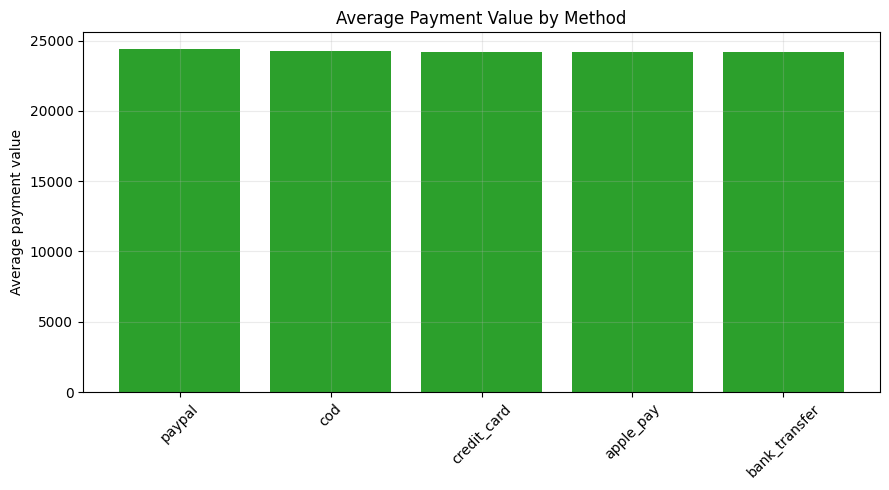

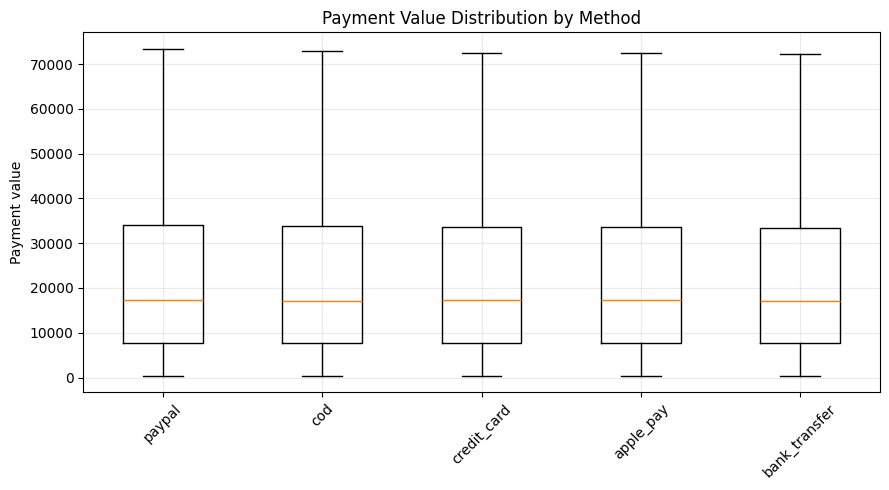

In [8]:
value_summary = pd.DataFrame()

if not payments_orders.empty and payment_cols.get('payment_amount'):
    value_summary = payments_orders.groupby('payment_method_std').agg(
        payment_count=('payment_amount_std', 'size'),
        avg_payment_value=('payment_amount_std', 'mean'),
        median_payment_value=('payment_amount_std', 'median'),
        std_payment_value=('payment_amount_std', 'std'),
        p25_payment_value=('payment_amount_std', lambda s: s.quantile(0.25)),
        p75_payment_value=('payment_amount_std', lambda s: s.quantile(0.75)),
        p90_payment_value=('payment_amount_std', lambda s: s.quantile(0.90)),
        total_payment_value=('payment_amount_std', 'sum'),
    ).reset_index().sort_values('avg_payment_value', ascending=False)
    display(value_summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    ordered = value_summary.sort_values('avg_payment_value', ascending=False)
    ax.bar(ordered['payment_method_std'].astype(str), ordered['avg_payment_value'], color='tab:green')
    ax.set_title('Average Payment Value by Method')
    ax.set_ylabel('Average payment value')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    groups = [payments_orders.loc[payments_orders['payment_method_std'] == m, 'payment_amount_std'].dropna().values for m in ordered['payment_method_std']]
    ax.boxplot(groups, tick_labels=ordered['payment_method_std'].astype(str), showfliers=False)
    ax.set_title('Payment Value Distribution by Method')
    ax.set_ylabel('Payment value')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Average payment value analysis is unavailable because payment amount was not identified.')

## 9. Cancel Rate by Payment Method

Compare cancellation concentration by payment method. This remains descriptive only.

,payment_method_std,total_records,cancelled_orders,returned_orders,failed_payments,completed_payments,cancel_rate,failed_payment_rate,completed_payment_rate
2,cod,96681,15468,8620,0,0,0.1600,0.0000,0.0000
4,paypal,97018,7817,4841,0,0,0.0806,0.0000,0.0000
0,apple_pay,64763,5190,3269,0,0,0.0801,0.0000,0.0000
3,credit_card,356352,28452,17807,0,0,0.0798,0.0000,0.0000
1,bank_transfer,32131,2535,1605,0,0,0.0789,0.0000,0.0000


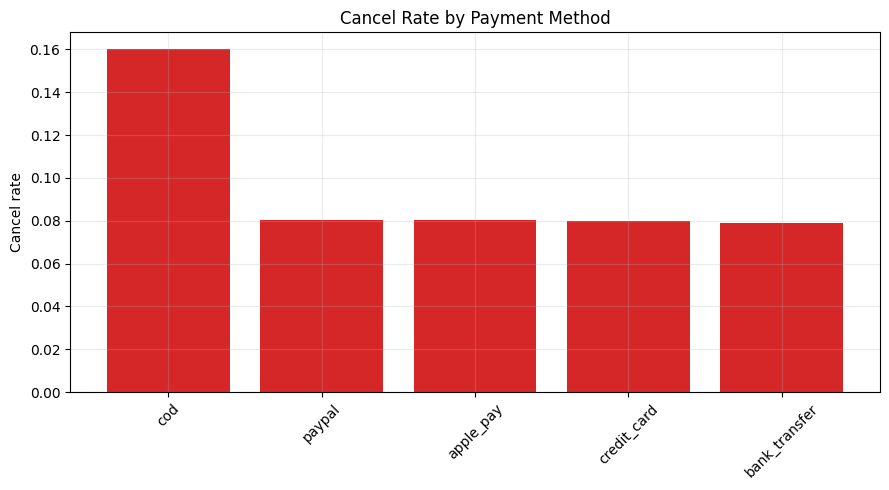

In [9]:
cancel_summary = pd.DataFrame()

if not payments_orders.empty and 'is_cancelled_order' in payments_orders.columns:
    cancel_summary = payments_orders.groupby('payment_method_std').agg(
        total_records=('order_id_std', 'size'),
        cancelled_orders=('is_cancelled_order', 'sum'),
        returned_orders=('is_returned_order', 'sum'),
        failed_payments=('is_failed_payment', 'sum'),
        completed_payments=('is_completed_payment', 'sum'),
    ).reset_index()
    cancel_summary['cancel_rate'] = cancel_summary['cancelled_orders'] / cancel_summary['total_records']
    cancel_summary['failed_payment_rate'] = cancel_summary['failed_payments'] / cancel_summary['total_records']
    cancel_summary['completed_payment_rate'] = cancel_summary['completed_payments'] / cancel_summary['total_records']
    cancel_summary = cancel_summary.sort_values('cancel_rate', ascending=False)
    display(cancel_summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(cancel_summary['payment_method_std'].astype(str), cancel_summary['cancel_rate'], color='tab:red')
    ax.set_title('Cancel Rate by Payment Method')
    ax.set_ylabel('Cancel rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Cancel-rate analysis is unavailable because cancellation status could not be derived.')

## 10. Payment Method Trend Over Time

Track monthly payment-method mix, value, and average value over time.

,month,payment_method_std,payment_count,total_payment_value,avg_payment_value,cancel_rate,month_total,method_share
0,2012-07-01,apple_pay,570,"13,983,370.5400","24,532.2290",0.0860,5294,0.1077
1,2012-07-01,bank_transfer,242,"6,191,605.3000","25,585.1459",0.0661,5294,0.0457
2,2012-07-01,cod,774,"20,143,829.0400","26,025.6189",0.1563,5294,0.1462
3,2012-07-01,credit_card,2938,"70,952,032.3500","24,149.7728",0.0813,5294,0.5550
4,2012-07-01,paypal,770,"19,135,936.2800","24,851.8653",0.0753,5294,0.1454
5,2012-08-01,apple_pay,707,"17,245,159.4900","24,392.0219",0.0905,6427,0.1100
6,2012-08-01,bank_transfer,297,"7,296,984.3500","24,568.9709",0.0741,6427,0.0462
7,2012-08-01,cod,937,"23,667,363.1000","25,258.6586",0.1473,6427,0.1458
8,2012-08-01,credit_card,3551,"88,547,164.2600","24,935.8390",0.0870,6427,0.5525
9,2012-08-01,paypal,935,"22,332,569.1100","23,885.1007",0.0813,6427,0.1455


,month,total_payment_value,payment_count,avg_payment_value,cancel_rate
0,2012-07-01,"130,406,773.5100",5294,"24,632.9380",0.0912
1,2012-08-01,"159,089,240.3100",6427,"24,753.2660",0.0948
2,2012-09-01,"129,307,133.8200",5219,"24,776.2280",0.0820
3,2012-10-01,"110,185,694.4500",4285,"25,714.2811",0.0835
4,2012-11-01,"98,186,295.2400",4142,"23,705.0447",0.1019
5,2012-12-01,"114,322,610.6900",6684,"17,103.9214",0.0895
6,2013-01-01,"91,285,449.8900",3665,"24,907.3533",0.0889
7,2013-02-01,"106,360,669.3000",4661,"22,819.2811",0.0953
8,2013-03-01,"141,545,691.4000",6590,"21,478.8606",0.0936
9,2013-04-01,"189,651,816.0100",8874,"21,371.6268",0.0943


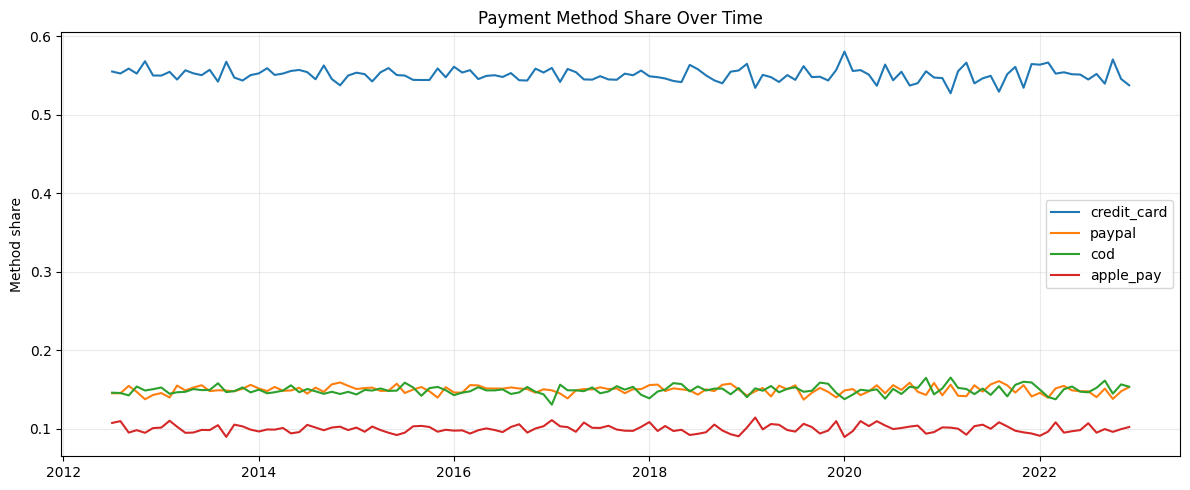

In [10]:
monthly_method = pd.DataFrame()
monthly_summary = pd.DataFrame()

if not payments_orders.empty and payments_orders['payment_date_std'].notna().any():
    pay = payments_orders.dropna(subset=['payment_date_std']).copy()
    pay['month'] = pay['payment_date_std'].dt.to_period('M').dt.to_timestamp()

    monthly_method = pay.groupby(['month', 'payment_method_std']).agg(
        payment_count=('order_id_std', 'size'),
        total_payment_value=('payment_amount_std', 'sum'),
        avg_payment_value=('payment_amount_std', 'mean'),
        cancel_rate=('is_cancelled_order', 'mean'),
    ).reset_index()
    month_totals = monthly_method.groupby('month')['payment_count'].sum().rename('month_total')
    monthly_method = monthly_method.merge(month_totals, on='month', how='left')
    monthly_method['method_share'] = monthly_method['payment_count'] / monthly_method['month_total']

    monthly_summary = pay.groupby('month').agg(
        total_payment_value=('payment_amount_std', 'sum'),
        payment_count=('order_id_std', 'size'),
        avg_payment_value=('payment_amount_std', 'mean'),
        cancel_rate=('is_cancelled_order', 'mean'),
    ).reset_index()
    display(monthly_method.head(10))
    display(monthly_summary.head(10))

    top_methods = monthly_method.groupby('payment_method_std')['payment_count'].sum().sort_values(ascending=False).head(4).index.tolist()
    fig, ax = plt.subplots(figsize=(12, 5))
    for method in top_methods:
        tmp = monthly_method.loc[monthly_method['payment_method_std'] == method]
        ax.plot(tmp['month'], tmp['method_share'], label=method)
    ax.set_title('Payment Method Share Over Time')
    ax.set_ylabel('Method share')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Payment trend analysis is unavailable because payment or fallback order dates are missing.')

## 11. Payment Value and Cancellation Over Time

Inspect whether payment value or cancel rate shows unusual periods.

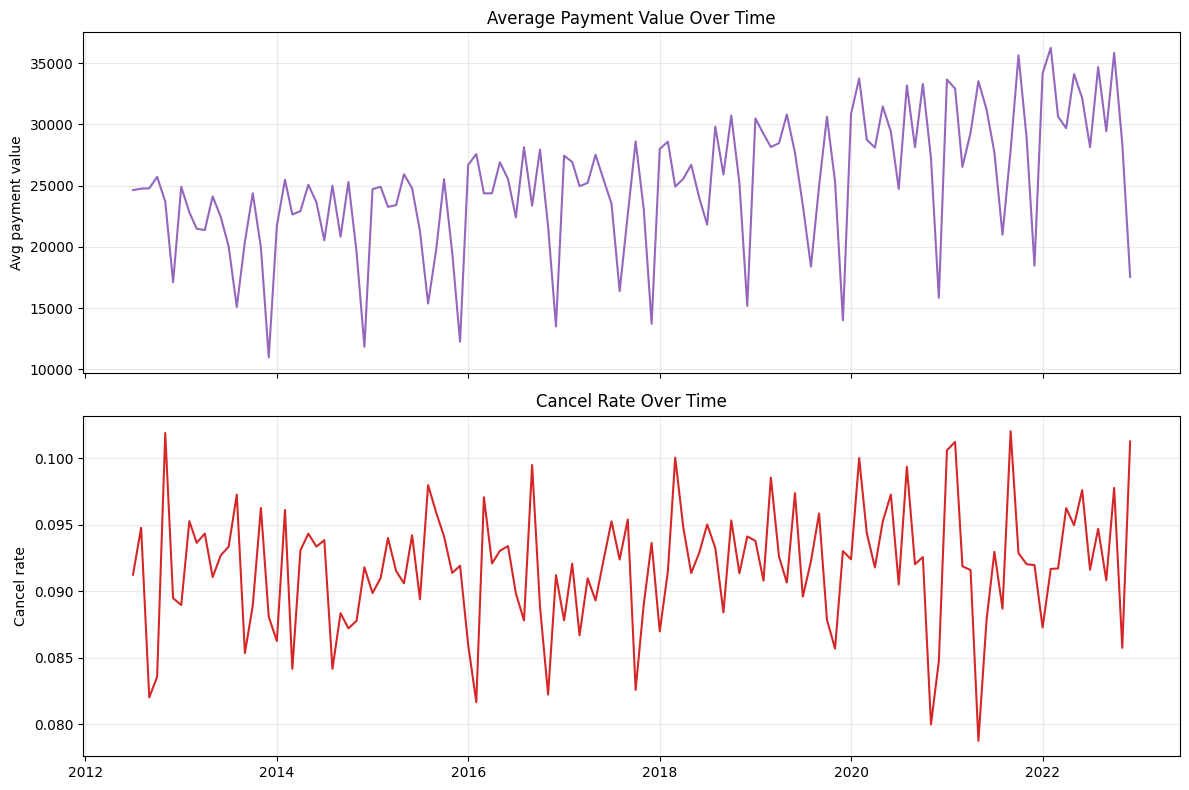

,month,total_payment_value,payment_count,avg_payment_value,cancel_rate
110,2021-09-01,"67,851,836.1000",2431,"27,911.0803",0.1020
4,2012-11-01,"98,186,295.2400",4142,"23,705.0447",0.1019
125,2022-12-01,"42,089,159.8100",2400,"17,537.1499",0.1013
103,2021-02-01,"65,046,263.9100",1976,"32,918.1498",0.1012
102,2021-01-01,"46,188,071.6500",1372,"33,664.7753",0.1006
68,2018-03-01,"159,928,140.4400",6418,"24,918.6881",0.1000
91,2020-02-01,"62,448,688.3600",1850,"33,756.0478",0.1000
50,2016-09-01,"131,984,939.2200",5650,"23,360.1662",0.0995
97,2020-08-01,"121,906,775.5100",3674,"33,180.9405",0.0993
80,2019-03-01,"113,416,476.1500",4029,"28,150.0313",0.0985


In [11]:
if not monthly_summary.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(monthly_summary['month'], monthly_summary['avg_payment_value'], color='tab:purple')
    axes[0].set_title('Average Payment Value Over Time')
    axes[0].set_ylabel('Avg payment value')

    axes[1].plot(monthly_summary['month'], monthly_summary['cancel_rate'], color='tab:red')
    axes[1].set_title('Cancel Rate Over Time')
    axes[1].set_ylabel('Cancel rate')
    plt.tight_layout()
    plt.show()

    display(monthly_summary.sort_values('cancel_rate', ascending=False).head(10))
else:
    print('Monthly payment value and cancellation trend could not be created.')

## 12. Leakage-Safe Payment Forecast Feature Preview

Build lagged historical payment features only. Future payment method mix is usually not known before prediction and must not be used directly.

In [12]:
feature_preview = pd.DataFrame()

if not monthly_method.empty and not monthly_summary.empty:
    feature_base = monthly_summary.copy().sort_values('month')

    dominant_share = monthly_method.groupby('month')['method_share'].max().rename('dominant_payment_method_share')
    feature_base = feature_base.merge(dominant_share, on='month', how='left')

    for method in ['credit_card', 'cod', 'bank_transfer', 'paypal', 'apple_pay', 'ewallet']:
        tmp = monthly_method.loc[monthly_method['payment_method_std'] == method, ['month', 'method_share']].rename(columns={'method_share': f'{method}_share'})
        feature_base = feature_base.merge(tmp, on='month', how='left')

    share_cols = [c for c in feature_base.columns if c.endswith('_share')]
    for col in share_cols:
        feature_base[col] = feature_base[col].fillna(0)

    feature_base['avg_payment_value_lag'] = feature_base['avg_payment_value'].shift(1)
    feature_base['payment_count_lag'] = feature_base['payment_count'].shift(1)
    feature_base['cancel_rate_lag'] = feature_base['cancel_rate'].shift(1)
    feature_base['failed_payment_rate_lag'] = np.nan
    feature_base['payment_method_share_lag'] = feature_base['dominant_payment_method_share'].shift(1)

    if 'credit_card_share' in feature_base.columns:
        feature_base['card_share_lag'] = feature_base['credit_card_share'].shift(1)
    if 'cod_share' in feature_base.columns:
        feature_base['cod_share_lag'] = feature_base['cod_share'].shift(1)
    if 'bank_transfer_share' in feature_base.columns:
        feature_base['bank_transfer_share_lag'] = feature_base['bank_transfer_share'].shift(1)
    if 'ewallet_share' in feature_base.columns:
        feature_base['ewallet_share_lag'] = feature_base['ewallet_share'].shift(1)

    preview_cols = [
        'month', 'total_payment_value', 'payment_count', 'avg_payment_value',
        'dominant_payment_method_share', 'payment_method_share_lag',
        'avg_payment_value_lag', 'payment_count_lag', 'cancel_rate_lag',
        'failed_payment_rate_lag'
    ]
    for optional_col in ['card_share_lag', 'cod_share_lag', 'bank_transfer_share_lag', 'ewallet_share_lag']:
        if optional_col in feature_base.columns:
            preview_cols.append(optional_col)

    feature_preview = feature_base[preview_cols].head(20)
    display(feature_preview)

print('All features shown above are lagged historical aggregates. They are safe only when computed from periods before the forecast date.')
print('Do not use current-period or future payment method mix directly unless that information is genuinely known before prediction.')

,month,total_payment_value,payment_count,avg_payment_value,dominant_payment_method_share,payment_method_share_lag,avg_payment_value_lag,payment_count_lag,cancel_rate_lag,failed_payment_rate_lag,card_share_lag,cod_share_lag,bank_transfer_share_lag,ewallet_share_lag
0,2012-07-01,"130,406,773.5100",5294,"24,632.9380",0.5550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-08-01,"159,089,240.3100",6427,"24,753.2660",0.5525,0.5550,"24,632.9380","5,294.0000",0.0912,NaN,0.5550,0.1462,0.0457,0.0000
2,2012-09-01,"129,307,133.8200",5219,"24,776.2280",0.5587,0.5525,"24,753.2660","6,427.0000",0.0948,NaN,0.5525,0.1458,0.0462,0.0000
3,2012-10-01,"110,185,694.4500",4285,"25,714.2811",0.5524,0.5587,"24,776.2280","5,219.0000",0.0820,NaN,0.5587,0.1427,0.0483,0.0000
4,2012-11-01,"98,186,295.2400",4142,"23,705.0447",0.5681,0.5524,"25,714.2811","4,285.0000",0.0835,NaN,0.5524,0.1540,0.0478,0.0000
5,2012-12-01,"114,322,610.6900",6684,"17,103.9214",0.5500,0.5681,"23,705.0447","4,142.0000",0.1019,NaN,0.5681,0.1490,0.0500,0.0000
6,2013-01-01,"91,285,449.8900",3665,"24,907.3533",0.5498,0.5500,"17,103.9214","6,684.0000",0.0895,NaN,0.5500,0.1507,0.0549,0.0000
7,2013-02-01,"106,360,669.3000",4661,"22,819.2811",0.5546,0.5498,"24,907.3533","3,665.0000",0.0889,NaN,0.5498,0.1528,0.0499,0.0000
8,2013-03-01,"141,545,691.4000",6590,"21,478.8606",0.5448,0.5546,"22,819.2811","4,661.0000",0.0953,NaN,0.5546,0.1448,0.0500,0.0000
9,2013-04-01,"189,651,816.0100",8874,"21,371.6268",0.5566,0.5448,"21,478.8606","6,590.0000",0.0936,NaN,0.5448,0.1467,0.0504,0.0000


All features shown above are lagged historical aggregates. They are safe only when computed from periods before the forecast date.
Do not use current-period or future payment method mix directly unless that information is genuinely known before prediction.


## 13. Key Observations and Warnings

Summarize the descriptive findings, data-quality issues, and recommended historical payment features.

In [13]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not method_summary.empty:
    top_count = method_summary.sort_values('payment_count', ascending=False).head(3)
    top_value = method_summary.sort_values('total_payment_value', ascending=False).head(3)
    summary_lines.append('- Most common payment methods by count: ' + ', '.join(f"{r.payment_method_std} ({r.payment_method_share:.2%})" for r in top_count.itertuples()) + '.')
    summary_lines.append('- Largest payment methods by total value: ' + ', '.join(f"{r.payment_method_std} ({r.payment_value_share:.2%})" for r in top_value.itertuples()) + '.')

if not value_summary.empty:
    top_avg = value_summary.sort_values('avg_payment_value', ascending=False).head(3)
    summary_lines.append('- Highest average payment value methods: ' + ', '.join(f"{r.payment_method_std} ({r.avg_payment_value:,.2f})" for r in top_avg.itertuples()) + '.')

if not cancel_summary.empty:
    top_cancel = cancel_summary.sort_values('cancel_rate', ascending=False).head(3)
    summary_lines.append('- Highest cancel-rate methods: ' + ', '.join(f"{r.payment_method_std} ({r.cancel_rate:.2%})" for r in top_cancel.itertuples()) + '.')

if not monthly_method.empty:
    mix_changes = monthly_method.groupby('payment_method_std')['method_share'].agg(lambda s: float(s.max() - s.min())).sort_values(ascending=False)
    most_variable = mix_changes.head(3)
    summary_lines.append('- Payment method mix changes over time, with largest share swings in: ' + ', '.join(f"{idx} ({val:.2%} range)" for idx, val in most_variable.items()) + '.')

if payment_warnings or join_warnings:
    summary_lines.append('- Payment data quality warnings: ' + '; '.join(payment_warnings + join_warnings))
else:
    summary_lines.append('- Payment data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe payment forecast features: payment_method_share_lag, avg_payment_value_lag, payment_count_lag, cancel_rate_lag, and method-specific share lags such as card_share_lag or cod_share_lag where relevant.')
summary_lines.append('- Future payment method mix must not be used directly for forecasting unless it is genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. Payment mix can vary with customer mix, channel, order size, promotions, geography, and operational policies.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Most common payment methods by count: credit_card (55.08%), paypal (15.00%), cod (14.94%).
- Largest payment methods by total value: credit_card (55.04%), paypal (15.07%), cod (14.97%).
- Highest average payment value methods: paypal (24,363.32), cod (24,275.17), credit_card (24,217.82).
- Highest cancel-rate methods: cod (16.00%), paypal (8.06%), apple_pay (8.01%).
- Payment method mix changes over time, with largest share swings in: credit_card (5.30% range), cod (3.45% range), apple_pay (2.48% range).
- Payment data quality warnings: none beyond the checks reported in notebook tables.
- Recommended leakage-safe payment forecast features: payment_method_share_lag, avg_payment_value_lag, payment_count_lag, cancel_rate_lag, and method-specific share lags such as card_share_lag or cod_share_lag where relevant.
- Future payment method mix must not be used directly for forecasting unless it is genuinely known before prediction.
- Causal caution: this is obs